**Program No. 23.  >> Secure Data Visualization Architecture**

**Objective:** To design a secure visualization system.

**Tasks:**
- Design secured data visualization architecture
- Explain security measures used

**Outcome:** Students will understand security considerations in visualization systems.


**Basic Visualization System (Insecure)**

Data Source → Processing → Visualization Dashboard

**Secure Visualization Architecture**
```
---
Data Source
    ↓
Data Encryption (AES / TLS)
    ↓
Secure Storage (Access-Controlled DB)
    ↓
Authentication & Authorization Layer
    ↓
Data Preprocessing & Validation
    ↓
Anomaly Detection Engine (ML)
    ↓
Secure Visualization Dashboard (Role-Based Access)
    ↓
Audit Logs & Monitoring
---
```

**Step 1: Import Libraries**

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

**Step 2: Create Secure Dataset**

In [2]:
np.random.seed(42)

data = pd.DataFrame({
    "Request_Count": np.random.normal(200, 30, 500),
    "Response_Time": np.random.normal(120, 20, 500),
    "Data_Transferred_MB": np.random.normal(50, 10, 500)
})

# Inject abnormal behavior
data.loc[480:499, "Request_Count"] = np.random.normal(500, 50, 20)

**Step 3: Apply Anomaly Detection**

In [3]:
model = IsolationForest(contamination=0.05)
data["Anomaly"] = model.fit_predict(data)

# -1 = anomaly, 1 = normal

**Step 4: Secure Visualization**

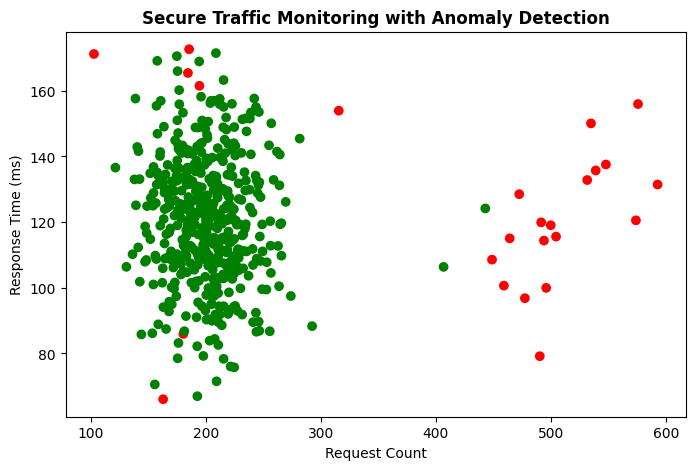

In [4]:
plt.figure(figsize=(8,5))

colors = data["Anomaly"].map({1: "green", -1: "red"})

plt.scatter(data["Request_Count"],
            data["Response_Time"],
            c=colors)

plt.title("Secure Traffic Monitoring with Anomaly Detection",
          fontweight="bold")

plt.xlabel("Request Count")
plt.ylabel("Response Time (ms)")

plt.show()

**Interactive IoT Device Monitoring Dashboard (Real-Time Simulated Data)**

In [6]:
# Objective:
# Create interactive visualizations to monitor device activity
# for pre-processed simulated IoT data streams in real-time.

# ------------------------------------------------------------
# Install & Import Required Libraries
# ------------------------------------------------------------
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'plotly', '-q'])
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Generate Simulated IoT Dataset
# ------------------------------------------------------------
np.random.seed(42)

devices = ['Thermostat', 'Camera', 'Door_Sensor', 'Light', 'Smoke_Detector']
hours = list(range(24))

records = []

for device in devices:
    for h in hours:
        base_temp = 25 + np.random.normal(0, 3)

        records.append({
            'Device': device,
            'Hour': h,
            'Temperature': round(base_temp, 1),
            'Status': np.random.choice(['Active','Idle','Alert'], p=[0.7,0.2,0.1]),
            'Battery': max(10, min(100, int(80 + np.random.normal(0, 15)))),
            'Data_Packets': np.random.randint(10, 200)
        })

iot_data = pd.DataFrame(records)

print("\n--- IoT Device Data (Sample) ---")
print(iot_data.head(10).to_string(index=False))

# ------------------------------------------------------------
# Create Interactive Dashboard (4-in-1 Panel)
# ------------------------------------------------------------
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        'Device Activity Timeline',
        'Average Battery Levels',
        'Data Packets Distribution',
        'Status Distribution'
    )
)

# ------------------------------------------------------------
# 1️⃣ Device Activity Timeline
# ------------------------------------------------------------
for device in devices:
    dev_data = iot_data[iot_data['Device'] == device]

    fig.add_trace(
        go.Scatter(
            x=dev_data['Hour'],
            y=dev_data['Data_Packets'],
            name=device,
            mode='lines+markers'
        ),
        row=1, col=1
    )

# ------------------------------------------------------------
# 2️⃣ Average Battery Level by Device
# ------------------------------------------------------------
avg_battery = iot_data.groupby('Device')['Battery'].mean()

fig.add_trace(
    go.Bar(
        x=avg_battery.index,
        y=avg_battery.values,
        marker_color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336'],
        name="Avg Battery"
    ),
    row=1, col=2
)

# ------------------------------------------------------------
# 3️⃣ Data Packets Distribution (Box Plot)
# ------------------------------------------------------------
fig.add_trace(
    go.Box(
        x=iot_data['Device'],
        y=iot_data['Data_Packets'],
        name="Packets Distribution"
    ),
    row=2, col=1
)

# ------------------------------------------------------------
# 4️⃣ Status Distribution (Stacked Bar)
# ------------------------------------------------------------
status_counts = iot_data.groupby(['Device','Status']).size().unstack(fill_value=0)

for status in ['Active','Idle','Alert']:
    if status in status_counts.columns:
        fig.add_trace(
            go.Bar(
                name=status,
                x=status_counts.index,
                y=status_counts[status]
            ),
            row=2, col=2
        )

# ------------------------------------------------------------
# Layout Settings
# ------------------------------------------------------------
fig.update_layout(
    height=750,
    title_text='IoT Device Monitoring Dashboard',
    title_font_size=18,
    showlegend=True,
    barmode='stack'
)

fig.show()

# ------------------------------------------------------------
# Alert Analysis
# ------------------------------------------------------------
alerts = iot_data[iot_data['Status']=='Alert']

print("\nExplanation:")
print(f"Total Records: {len(iot_data)}")
print(f"Alerts: {len(alerts)}")
print(f"Alert Rate: {len(alerts)/len(iot_data)*100:.1f}%")

for d in devices:
    dev_alerts = len(alerts[alerts['Device']==d])
    if dev_alerts > 0:
        print(f"{d}: {dev_alerts} alerts")


--- IoT Device Data (Sample) ---
    Device  Hour  Temperature Status  Battery  Data_Packets
Thermostat     0         26.5   Idle       77           198
Thermostat     1         21.4 Active      100            97
Thermostat     2         22.3 Active       73            62
Thermostat     3         23.3 Active       72            67
Thermostat     4         17.2 Active       94            68
Thermostat     5         23.4  Alert       78            24
Thermostat     6         29.4 Active       76            64
Thermostat     7         24.9   Idle       85           144
Thermostat     8         23.2 Active       94            93
Thermostat     9         27.3 Active       63            17



Explanation:
Total Records: 120
Alerts: 12
Alert Rate: 10.0%
Thermostat: 2 alerts
Door_Sensor: 4 alerts
Light: 2 alerts
Smoke_Detector: 4 alerts
